In [5]:
import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square
from blochK.utils.hamiltonian_fct import operator_expand_dims,s0,sx,sy,sz
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma
import blochK

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
from alter_surf.utils3D import projector2layer

from numpy import cos, sin 

from tqdm import tqdm
import pickle

In the entire script $k_z$ is the out of plane direction and $k_x,k_y$ are in plane. This makes more sense but is rotated with respect to the nature paper. This is implementing the stuff Fernando has on the overleaf

$(k_x,k_y,k_z) \rightarrow (k_x,k_z,-k_y)$

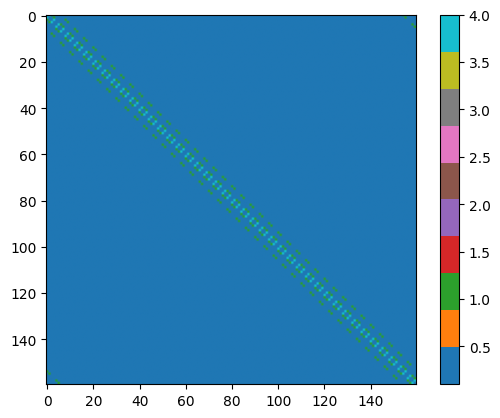

In [2]:
def H_2D_fct(kx,ky,t=0,t1=0,t2=0,tz=0,t3=0,t4=0,txy=0,Delta0=0,Delta1=0,Delta2=0,Delta3=0,lambda2=0,mu=0,kz=0): 
    """
    translation invariant model of CuMnAs with kz as additional parameter
    ----------
    Parameters: (I just sticked with Fernando's notation)
    t: NN hopping in (x,y) plane?
    t3 NN hopping in (x,y) plane?
    tz: NN hopping in z direction?
    Delta1: splitting induced by staggered magnetism?
    Delta2: splitting induced by staggered magnetism?
    lambda2: SOC strength
    mu: Fermi energy
    kz: momentum in z direction
    """
    n_orbitals2D = 8
    Hk = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex) # s, tau, sigma

    [s0_,sx_,sy_,sz_] = operator_expand_dims([s0,sx,sy,sz],kx)

    ck_p = cos((kx+ky)/2) + cos((kx-ky)/2)
    sk_p = sin((kx+ky)/2) + sin((kx-ky)/2)
    ck_m = cos((kx+ky)/2) - cos((kx-ky)/2)
    sk_m = sin((kx+ky)/2) - sin((kx-ky)/2)

    #define hamiltonian for each spin sector
    def Hk_spin(spin:int):
        Hk = np.zeros((n_orbitals2D//2,n_orbitals2D//2,*kx.shape),dtype=complex) #tau, sigma
        Hk[0,0] = Hk[1,1] = Hk[2,2] = Hk[3,3] = -mu - 2*txy*(cos(kx)+cos(ky))
        
        #NN hoppings
        Hk[0,1] += 2*t*ck_p - 1j*spin*Delta0*sk_m
        Hk[2,3] += 2*t*ck_p - 1j*spin*Delta0*sk_m
        Hk[0,2] += 2*tz*cos(kz/2)
        Hk[1,3] += 2*tz*cos(kz/2)

        #NNN hoppings
        Hk[0,2] += -2j*Delta1*spin*sin(kz/2)
        Hk[1,3] += +2j*Delta1*spin*sin(kz/2)
        Hk[0,3] += +2j*Delta2*sk_m*spin*cos(kz/2) + 2j*Delta3*ck_m*spin*sin(kz/2)
        Hk[1,2] += -2j*Delta2*sk_m*spin*cos(kz/2) + 2j*Delta3*ck_m*spin*sin(kz/2)

        return Hk
    
    #coupling between spin sectors due to SOC
    Hk_SOC = np.zeros((n_orbitals2D//2,n_orbitals2D//2,*kx.shape),dtype=complex) #tau, sigma
    Hk_SOC[0,1] += +lambda2*ck_p
    Hk_SOC[1,0] += -lambda2*ck_p
    Hk_SOC[2,3] += -lambda2*ck_p
    Hk_SOC[3,2] += +lambda2*ck_p

    #set hamiltonian structure
    Hk[:4,:4] = Hk_spin(spin=1)
    Hk[4:,4:] = Hk_spin(spin=-1)
    Hk[:4,4:] = Hk_SOC
    
    # make hermitian
    Hk = blochK.hamiltonian_fct.make_hermitian(Hk)

    return Hk


def H_3D_fct(kx,ky,len_z=2,t=0,t1=0,t2=0,tz=0,t3=0,t4=0,txy=0,Delta0=0,Delta1=0,Delta2=0,Delta3=0,lambda2=0,mu=0,PBC=False): 
    """
    3D model of CuMnAs in slab geometry with len_z layers in z-direction
    ----------
    len_z: number of layers in z-direction
    Parameters: (I just sticked with Fernando's notation)
    t: NN hopping in (x,y) plane?
    tz: NN hopping in z direction?
    Delta1: splitting induced by staggered magnetism?
    Delta2: splitting induced by staggered magnetism?
    lambda2: SOC strength
    mu: Fermi energy
    PBC: periodic boundary conditions in z-direction
    """
    n_orbitals2D = 8 #number of orbitals in unit cell
    Hk = np.zeros((n_orbitals2D*len_z,n_orbitals2D*len_z,*kx.shape),dtype=complex)

    ck_p = cos((kx+ky)/2) + cos((kx-ky)/2)
    sk_p = sin((kx+ky)/2) + sin((kx-ky)/2)
    ck_m = cos((kx+ky)/2) - cos((kx-ky)/2)
    sk_m = sin((kx+ky)/2) - sin((kx-ky)/2)

    #define hamiltonian for each spin sector
    def H2D_spin(spin:int):
        """Intralayer hoppings"""
        Hk = np.zeros((4,4,*kx.shape),dtype=complex) #tau, sigma
        Hk[0,0] = Hk[1,1] = Hk[2,2] = Hk[3,3] = -mu - 2*txy*(cos(kx)+cos(ky))
        
        #NN hoppings
        Hk[0,1] += 2*t*ck_p - 1j*spin*Delta0*sk_m
        Hk[2,3] += 2*t*ck_p - 1j*spin*Delta0*sk_m
        Hk[0,2] += tz
        Hk[1,3] += tz

        #NNN hoppings
        Hk[0,2] += -Delta1*spin
        Hk[1,3] += +Delta1*spin
        Hk[0,3] +=  1j*Delta2*sk_m*spin + Delta3*ck_m*spin
        Hk[1,2] += -1j*Delta2*sk_m*spin + Delta3*ck_m*spin

        return Hk
    
    def Hz_spin(spin:int):
        """Interlayer hoppings. Hk[i,j] = Hz[i,j-4]"""
        Hk = np.zeros((4,4,*kx.shape),dtype=complex)

        #NN hoppings
        Hk[3,1] += tz 
        Hk[2,0] += tz 

        #NNN hoppings
        Hk[2,0] += +Delta1*spin
        Hk[3,1] += -Delta1*spin
        Hk[2,1] +=  1j*Delta2*sk_m*spin - Delta3*ck_m*spin 
        Hk[3,0] += -1j*Delta2*sk_m*spin - Delta3*ck_m*spin

        return Hk
    
    def Hk_SOC_layer():
        """Intralayer SOC hoppings"""
        Hk = np.zeros((4,4,*kx.shape),dtype=complex) #tau, sigma
        Hk[0,1] += +lambda2*ck_p
        Hk[1,0] += -lambda2*ck_p
        Hk[2,3] += -lambda2*ck_p
        Hk[3,2] += +lambda2*ck_p
        return Hk

    #hoppings in x,y plane
    Hk_2D = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex)
    Hk_2D[:4,:4] = H2D_spin(spin=1)
    Hk_2D[4:,4:] = H2D_spin(spin=-1)
    Hk_2D[:4,4:] = Hk_SOC_layer()
    Hk_2D = blochK.hamiltonian_fct.make_hermitian(Hk_2D)
    
    #fill diagonal blocks
    for j in range(len_z):
         Hk[n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D, n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D] = Hk_2D

    #hoppings in z-direction, 3D
    Hz = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex)
    Hz[:4,:4] = Hz_spin(spin=1)
    Hz[4:,4:] = Hz_spin(spin=-1)
    #add NN hoppings in z-direction blocks
    for j in range(len_z-1):
        Hk[n_orbitals2D*j:n_orbitals2D*(j+1), n_orbitals2D*(j+1):n_orbitals2D*(j+2)] = Hz #upper block

    if PBC: # Periodic boundary conditions
        Hk[0:n_orbitals2D,n_orbitals2D*(len_z-1):n_orbitals2D*len_z] = np.swapaxes(np.conjugate(Hz),0,1)

    # add lower block by hermiticity
    Hk = blochK.hamiltonian_fct.make_hermitian(Hk)
    
    return Hk



Hparam0 = dict(t=1, tz=1,t3=0, Delta1=0, Delta2=1, mu=0)
H2D = blochK.Hamiltonian2D(H_2D_fct, param=Hparam0, basis = ['spin','z-layer','sublattice'])
H2D.add_operator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


Hparam0 = dict(len_z=20, t=1, tz=1,t3=0, Delta1=0, Delta2=0, mu=0, PBC=True)
H = blochK.Hamiltonian2D(H_3D_fct, param=Hparam0)
H.add_suboperator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))
H.add_operator('spin',np.kron(np.ones(Hparam0['len_z']),np.array([1,1,1,1,-1,-1,-1,-1])))

# Hparam_hierachy = dict(t=10, tz=20,t1=30,t3=0,Delta1=50, Delta2=60, Delta3=70, mu=0)
ks=H.BZ.sample(31)
Hk = H.evaluate(*ks)#,override_params=Hparam_hierachy)
Hk = np.abs(Hk).max(axis=(-2,-1))

vmax = Hk.max()
im = plt.imshow(Hk.real,vmin=0.1,vmax=vmax,cmap='tab10')
plt.colorbar(im)


## Looking at different k_z momenta

I pushed the Fermi energy a little bit down to see the Fermi surface of the 2 bands which merge to create the nodal line.

Nodal line seems to persist away from $k_z=0$?

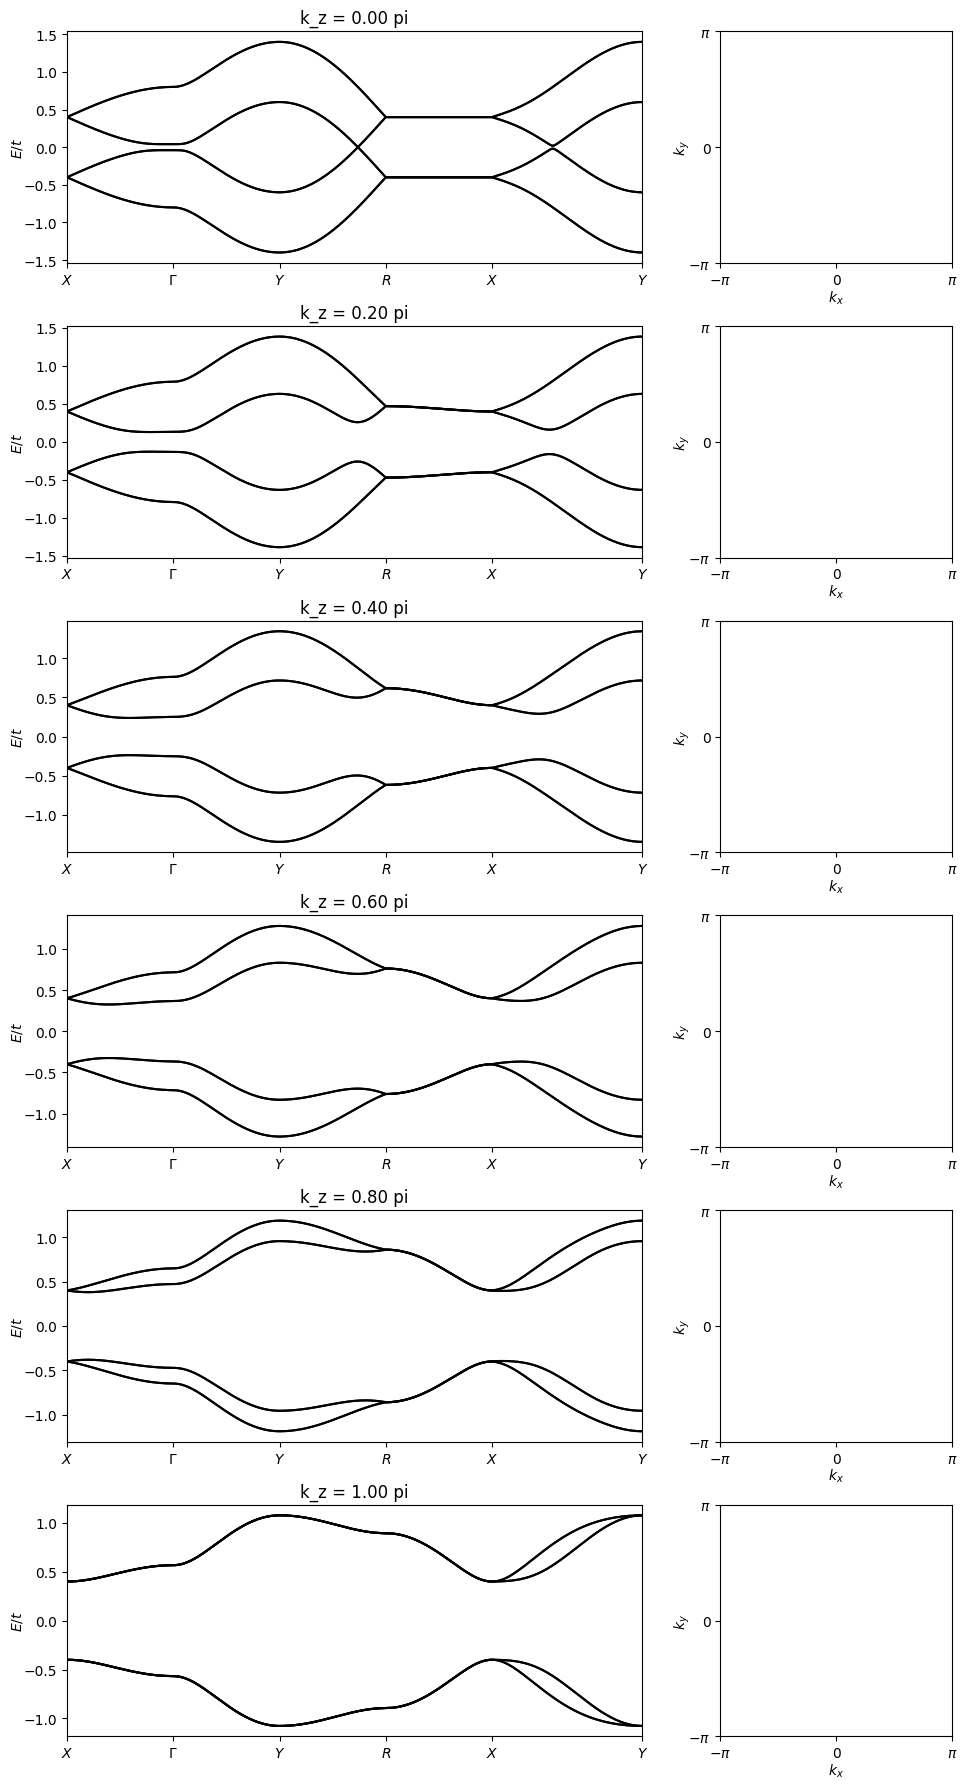

In [3]:
#Hparam0 = dict(t=0.4, tz=1, Delta2=0.6,Delta1=0.4, mu=-0.0)
Hparam0 = dict(t=0.2, tz=1, Delta2=0.6,Delta1=0.2,Delta3=0.2, mu=-0.0)
Hparam0 = dict(t=0.1, tz=0.2, Delta0=0.5,Delta1=0.2,Delta3=0.2,lambda2=0.02, mu=-0.,)

Hparams = dict(**Hparam0,kz=np.linspace(0,np.pi,6)) #np.linspace(0,np.pi,4)

#Delta2 creates the Blob at Y
#tz split it to get Nodal line
#t nodal line elongated along Y

#checked and gives the same results as H_3D_fct
#Delta1

Hparam_list = blochK.utils.parameters.dict2listofdict(Hparams)

labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = H2D.operator.spin
cmap = 'bwr'


fig, axs = plt.subplots(len(Hparam_list),2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3*len(Hparam_list)))

for Hparam_iter,ax in zip(Hparam_list, axs):
    ax[0].set_title(f'k_z = {Hparam_iter["kz"]/np.pi:.2f} pi')
    H2D.set_params(Hparam_iter)
    plot_bandstruc(ax[0],H2D,labels_points_path=labels,cmap=cmap)
    plot_FS(ax[1],H2D,cmap=cmap,Lk=50,print_filling=False)

plt.tight_layout()

## Looking at the Projection along z-direction

This looks roughly the same. There is a flat band connecting the Weyl cones for slab geometry and PBC. I guess this is the nodal line? No this doesn't make sense. It seems like one of the 2 bands we have in becomes this flat state?

{'t': 0.1, 'tz': 0.2, 'Delta0': 0.5, 'Delta1': 0.2, 'Delta3': 0.2, 'lambda2': 0.02, 'mu': -0.0, 'kz': np.float64(3.141592653589793)}
{'len_z': 20, 't': 0.1, 'tz': 0.2, 't3': 0, 'Delta1': 0.2, 'Delta2': 0, 'mu': -0.0, 'PBC': True, 'Delta0': 0.5, 'Delta3': 0.2, 'lambda2': 0.02}


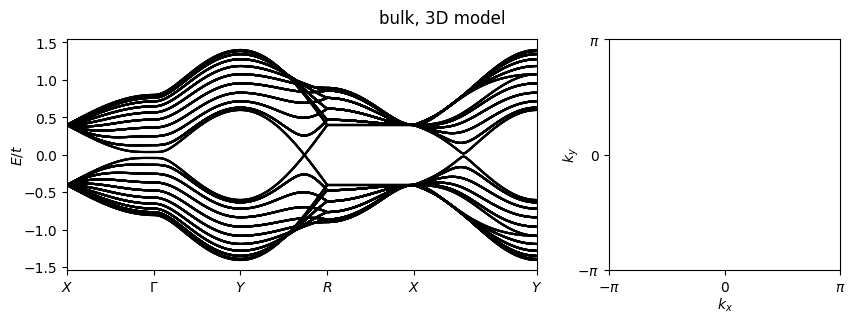

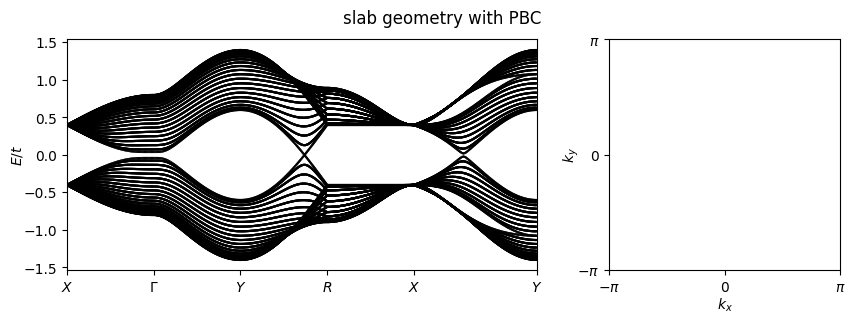

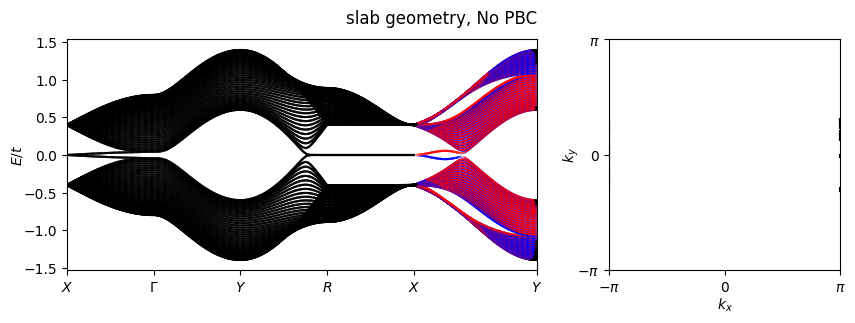

In [4]:
Hparam = Hparam0.copy()

H2D.update_params(Hparam)
H.update_params(Hparam)

print(H2D.param)
print(H.param)

labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'

#2D model
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('bulk, 3D model')
for kz in np.linspace(-2*np.pi,2*np.pi,H.param['len_z'],endpoint=False):
    H2D.update_params(dict(kz=kz))
    plot_bandstruc(ax,H2D,labels_points_path=labels,cmap=cmap,coloring_operator=H2D.operator.spin)
    plot_FS(ax1,H2D,cmap=cmap,coloring_operator=H2D.operator.spin,Lk=50,)

#with PBC
H.update_params(dict(PBC=True))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry with PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=H.operator.spin)
plot_FS(ax1,H,cmap=cmap,coloring_operator=H.operator.spin,Lk=50,)

#without PBC
H.update_params(dict(PBC=False))
fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry, No PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=H.operator.spin)
plot_FS(ax1,H,cmap=cmap,coloring_operator=H.operator.spin,Lk=50,)


## Computing surface properties

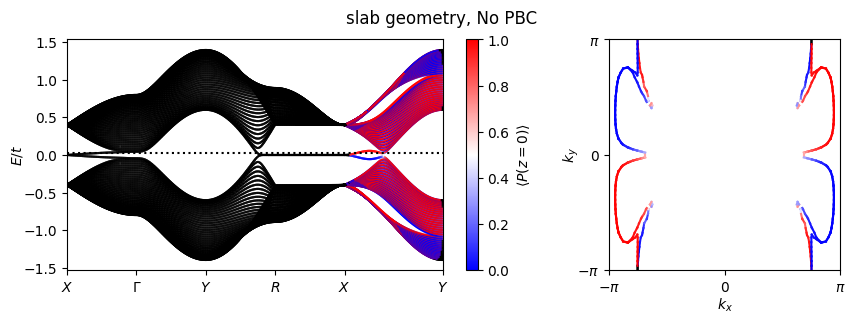

In [7]:
#without PBC
mu = 0.02
H.update_params(Hparam0)
H.update_params(dict(PBC=False))

labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = H.operator.spin #np.kron(projector2layer(0,H.param['len_z']),H.suboperator.spin)
cmap = 'bwr' #'Greys'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('slab geometry, No PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap,coloring_operator=coloring_operator,threshold_degeneracy=2)
ax.axhline(mu,color='k',ls=':' )
H.update_params(dict(mu=mu))
plot_FS(ax1,H,cmap=cmap,coloring_operator=coloring_operator,Lk=50,threshold_degeneracy=2)
H.update_params(dict(mu=0))
cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='vertical')
cbar.set_label(r'$\langle P(z=0) \rangle $')

In [8]:
Lk = 100 #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lk)
#Diagonalize Hamiltonian
H.update_params(dict(PBC=False))
len_z = H.param['len_z']
es,psis = H.diagonalize(*ks)


def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin='',linthresh=1e-2):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.SymLogNorm(linthresh=linthresh,vmin=vmin,vmax=vmax))
    return im




Gamma = 0.005


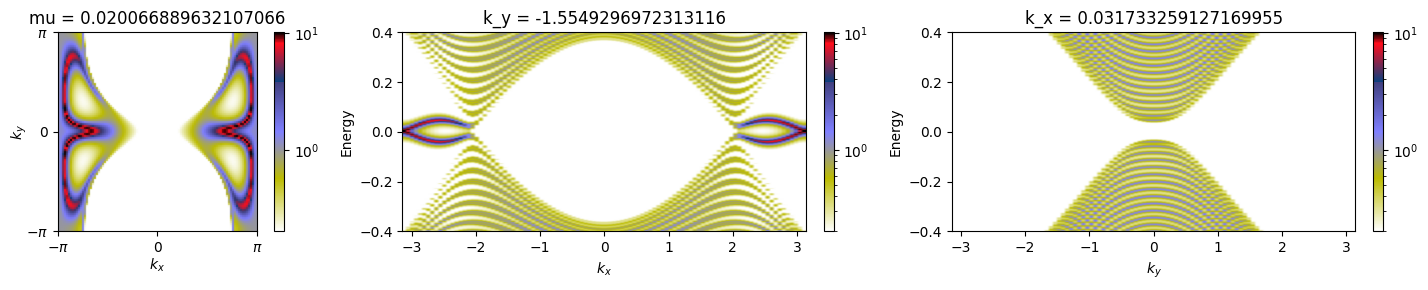

In [9]:
mu = 0.02 #energy at which the momentum resolved spectral density is computed
energies = np.linspace(-0.4,0.4,300)

layer=0
Gamma = 0.005#find_Gamma(es)
print(f'Gamma = {Gamma}')
proj_2layers = projector2layer(layer,len_z=len_z)

#compute spectral density
Os = exp_value_O(np.kron(proj_2layers,np.ones(H.n_orbitals//len_z)),psis) #.shape=(n,kx,ky)

spectral_density0 = np.sum(Os[None]*Gamma/((es[None]-energies[:,None,None,None])**2+Gamma**2),axis=1)/len_z #.shape=(len(energies),kx,ky)


fig,axs = plt.subplots(1,3,figsize=(16,3))

#kx,ky - Plot
idx_mu = np.argmin(np.abs(energies-mu))
axs[0].set_title(f'mu = {energies[idx_mu]}')
vmax = np.abs(spectral_density0[idx_mu]).max()
im = plot_spectral_density(axs[0],spectral_density0[idx_mu],show_ylabel=(layer==0),show_xlabel=True,vmax=vmax,vmin=2e-1,cmap='gist_stern_r')
plt.colorbar(im,ax=axs[0],fraction=0.046,pad=0.04)


#kx,energy - Plot
idx_ky = Lk//4
axs[1].set_title(f'k_y = {ks[1,0,idx_ky]}')
#vmax = np.abs(spectral_density0[:,:,idx_ky]).max()
im = axs[1].imshow(spectral_density0[:,:,idx_ky],norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=vmax),cmap='gist_stern_r',extent=(-pi,pi,energies[0],energies[-1]),origin='lower',aspect='auto')
axs[1].set_xlabel('$k_x$')
axs[1].set_ylabel('Energy')
plt.colorbar(im,ax=axs[1],fraction=0.046,pad=0.04)

#ky,energy - Plot
idx_kx = Lk//2
axs[2].set_title(f'k_x = {ks[0,idx_kx,0]}')
#vmax = np.abs(spectral_density0[:,idx_kx]).max()
im = axs[2].imshow(spectral_density0[:,idx_kx],norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=vmax),cmap='gist_stern_r',extent=(-pi,pi,energies[0],energies[-1]),origin='lower',aspect='auto')
axs[2].set_xlabel('$k_y$')
axs[2].set_ylabel('Energy')
plt.colorbar(im,ax=axs[2],fraction=0.046,pad=0.04)

plt.tight_layout()



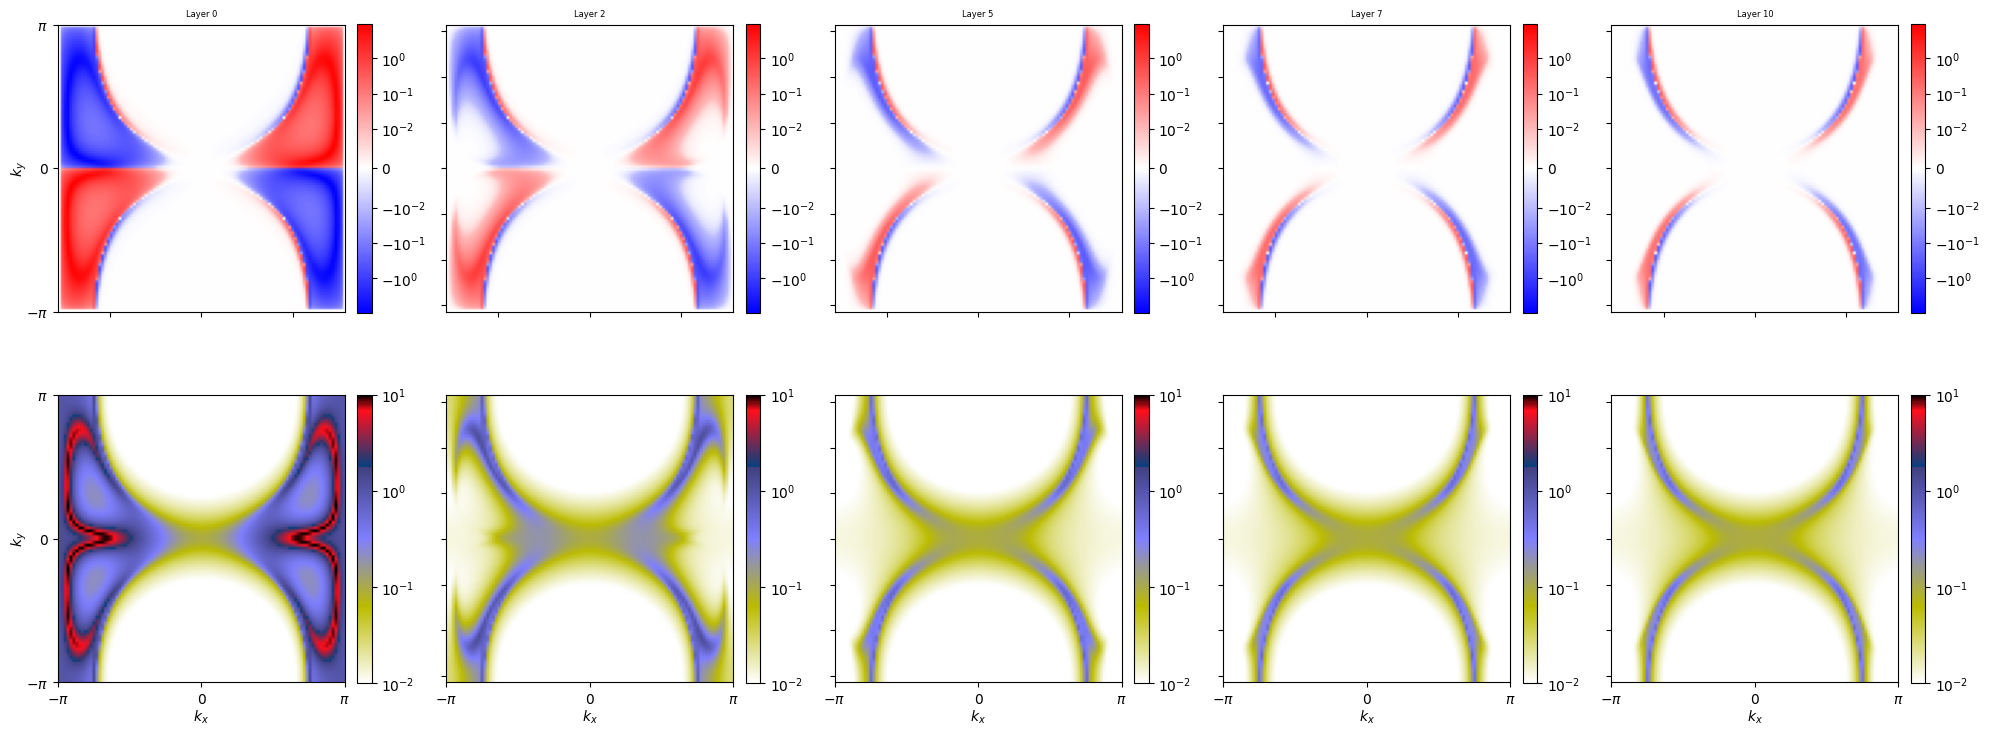

In [15]:
mu = 0.02
layers = np.linspace(0,len_z//2,5,dtype=int)
Gamma = 0.005#find_Gamma(es)

#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,H.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(H.n_orbitals//len_z)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z

    if layer == 0:
        vmax_spin = np.abs(spectral_density_spin).max()
        vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin,vmin=-vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=1e-2,cmap='gist_stern_r')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()


In [ ]:
## creating the spectral density data

layers = np.arange(0,len_z-1,1,dtype=int)

spectral_densitys = []
spin_spectral_densitys = []
for layer in tqdm(layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    proj_spin = np.kron(proj_2layers,H.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(proj_spin,psis) #.shape=(n,y,x)
    spin_spectral_density = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z
    spin_spectral_densitys.append(spin_spectral_density)
    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,(H.suboperator.spin>0)*1.),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/((es-mu)**2+Gamma**2),axis=0)/len_z
    spectral_densitys.append(spectral_density0)

spectral_densitys = np.array(spectral_densitys)
spin_spectral_densitys = np.array(spin_spectral_densitys)

with open('analysis/spectral_densitys_Weyl.pkl','wb') as f:
    pickle.dump({'spectral_density':spectral_densitys,
                 'spin_spectral_density':spin_spectral_densitys,
                 'layers':layers,
                 'k_mesh':ks}, f)
f.close()



  0%|          | 0/19 [00:00<?, ?it/s]

In [62]:
L=10
np.linspace(0,L,L,endpoint=False)

np.linspace(0,2*np.pi,L,endpoint=False)/2/np.pi

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [ ]:
im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=)


NameError: name 'spectral_density' is not defined

In [ ]:
matplotlib.colors.SymLogNorm()

Init signature:
matplotlib.colors.SymLogNorm(
    linthresh,
    linscale=1.0,
    vmin=None,
    vmax=None,
    clip=False,
    *,
    base=10,
)
Docstring:     
The symmetrical logarithmic scale is logarithmic in both the
positive and negative directions from the origin.

Since the values close to zero tend toward infinity, there is a
need to have a range around zero that is linear.  The parameter
*linthresh* allows the user to specify the size of this range
(-*linthresh*, *linthresh*).

Parameters
----------
linthresh : float
    The range within which the plot is linear (to avoid having the plot
    go to infinity around zero).
linscale : float, default: 1
    This allows the linear range (-*linthresh* to *linthresh*) to be
    stretched relative to the logarithmic range. Its value is the
    number of decades to use for each half of the linear range. For
    example, when *linscale* == 1.0 (the default), the space used for
    the positive and negative halves of the linear range w